# Part 3: Seismic Vulnerability Index (SVI) Computation

This part of the workflow develops a Seismic Vulnerability Index (SVI) for each bridge using bridge-specific structural and condition-related attributes. Unlike HAZUS, which assigns vulnerability through predefined bridge classes and fragility parameters, SVI provides a continuous score that reflects the intrinsic vulnerability of each bridge.

The SVI framework uses bridge characteristics such as year built, reconstructed year, skew, number of spans, maximum span length, and condition rating. Each variable is converted into a normalized vulnerability score and then combined into a weighted index. The final SVI value ranges from 0 to 1, where higher values indicate greater structural vulnerability.

This step is important because it creates a more interpretable bridge-level vulnerability metric that can be compared against the HAZUS-based Expected Damage Ratio. It also provides a bridge-specific feature that can later be used in machine learning models.

The output of this step is a bridge-level dataset containing:
- cleaned bridge attributes used for SVI
- normalized vulnerability component scores
- final SVI score
- comparison-ready data for later analysis

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

DOWNLOADS = Path.home() / "Downloads"
INPUT_CSV = DOWNLOADS / "bridges_with_edr.csv"
OUT_SVI_CSV = DOWNLOADS / "bridges_with_svi.csv"

bridge_df = pd.read_csv(INPUT_CSV, low_memory=False)

def clean_int_series(s):
    return pd.to_numeric(s, errors="coerce")

def clean_float_series(s):
    return pd.to_numeric(s, errors="coerce")

bridge_df["year"] = clean_int_series(bridge_df["YEAR_BUILT_027"])

bridge_df["yr_recon"] = (
    bridge_df["YEAR_RECONSTRUCTED_106"]
    .astype(str)
    .str.extract(r"(\d{4})")[0]
    .pipe(pd.to_numeric, errors="coerce")
)

bridge_df["spans"] = clean_int_series(bridge_df["MAIN_UNIT_SPANS_045"])
bridge_df["max_span"] = clean_float_series(bridge_df["MAX_SPAN_LEN_MT_048"])
bridge_df["skew"] = clean_float_series(bridge_df["DEGREES_SKEW_034"])

if "LOWEST_RATING" in bridge_df.columns:
    bridge_df["cond"] = clean_float_series(bridge_df["LOWEST_RATING"])
elif "SUBSTRUCTURE_COND_060" in bridge_df.columns:
    bridge_df["cond"] = clean_float_series(bridge_df["SUBSTRUCTURE_COND_060"])
else:
    bridge_df["cond"] = np.nan

def minmax_scale(series):
    s = pd.to_numeric(series, errors="coerce")
    smin = s.min(skipna=True)
    smax = s.max(skipna=True)
    if pd.isna(smin) or pd.isna(smax) or smax == smin:
        return pd.Series(np.nan, index=s.index)
    return (s - smin) / (smax - smin)

bridge_df["score_year"] = minmax_scale(2025 - bridge_df["year"])
bridge_df["score_recon"] = minmax_scale((2025 - bridge_df["yr_recon"]).fillna(2025 - bridge_df["year"]))
bridge_df["score_skew"] = minmax_scale(bridge_df["skew"])
bridge_df["score_spans"] = minmax_scale(bridge_df["spans"])
bridge_df["score_max_span"] = minmax_scale(bridge_df["max_span"])
bridge_df["score_cond"] = minmax_scale(9 - bridge_df["cond"])

weights = {
    "score_year": 0.20,
    "score_recon": 0.10,
    "score_skew": 0.15,
    "score_spans": 0.10,
    "score_max_span": 0.15,
    "score_cond": 0.30,
}

bridge_df["SVI_RAW"] = (
    bridge_df["score_year"] * weights["score_year"] +
    bridge_df["score_recon"] * weights["score_recon"] +
    bridge_df["score_skew"] * weights["score_skew"] +
    bridge_df["score_spans"] * weights["score_spans"] +
    bridge_df["score_max_span"] * weights["score_max_span"] +
    bridge_df["score_cond"] * weights["score_cond"]
)

bridge_df["SVI"] = minmax_scale(bridge_df["SVI_RAW"])

comparison_cols = [
    "STRUCTURE_NUMBER_008", "year", "yr_recon", "skew",
    "spans", "max_span", "cond", "SVI", "EDR", "HWB_CLASS"
]

print(bridge_df[comparison_cols].head())
print(bridge_df["SVI"].describe())
print(bridge_df[["SVI", "EDR"]].corr())

bridge_df.to_csv(OUT_SVI_CSV, index=False)
print("Saved:", OUT_SVI_CSV)

  STRUCTURE_NUMBER_008  year  yr_recon  skew  spans  max_span  cond       SVI  \
0              1CA0070  1949       NaN     0      1      10.4     4  0.550798   
1              1CA0095  1985       NaN     0      5      18.9     6  0.310526   
2              1CA0141  1948    1960.0     0      4       6.9     5  0.483242   
3              1CA0142  1948    1960.0     0      4       6.9     4  0.539486   
4              1CA0482  1971       NaN    33     15       4.3     6  0.445555   

        EDR HWB_CLASS  
0  0.019005      HWB2  
1  0.000010      HWB5  
2  0.020334      HWB2  
3  0.020334      HWB2  
4  0.000021      HWB6  
count    16796.000000
mean         0.403508
std          0.124930
min          0.000000
25%          0.319175
50%          0.396508
75%          0.484063
max          1.000000
Name: SVI, dtype: float64
          SVI       EDR
SVI  1.000000  0.017618
EDR  0.017618  1.000000
Saved: /Users/nchatterjee/Downloads/bridges_with_svi.csv


# Part 3 Plots: SVI Distribution and Comparison with HAZUS Damage

These plots are used to understand how the Seismic Vulnerability Index behaves across the bridge dataset and how it compares with the HAZUS-based Expected Damage Ratio.

The SVI histogram shows the overall spread of bridge vulnerability scores. The scatter plot between SVI and EDR helps examine whether bridges with higher intrinsic vulnerability also tend to show higher expected damage. The spatial SVI map shows where vulnerable bridges are distributed geographically. The boxplot by HAZUS class helps compare the continuous SVI measure against the categorical HAZUS bridge classification.

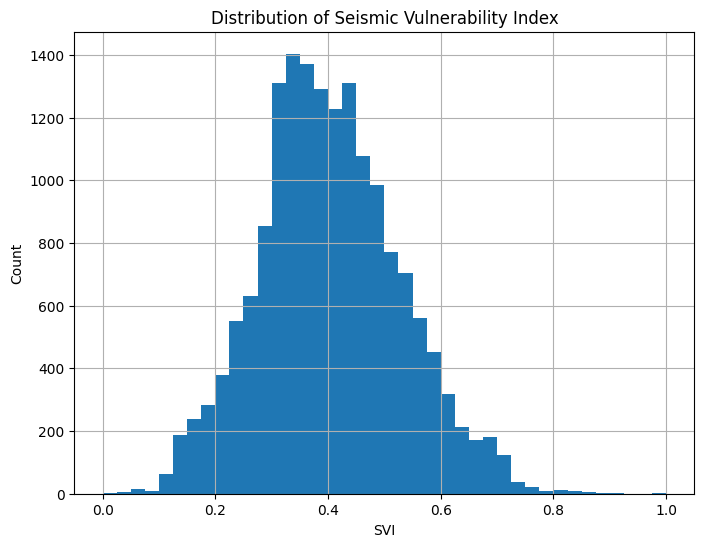

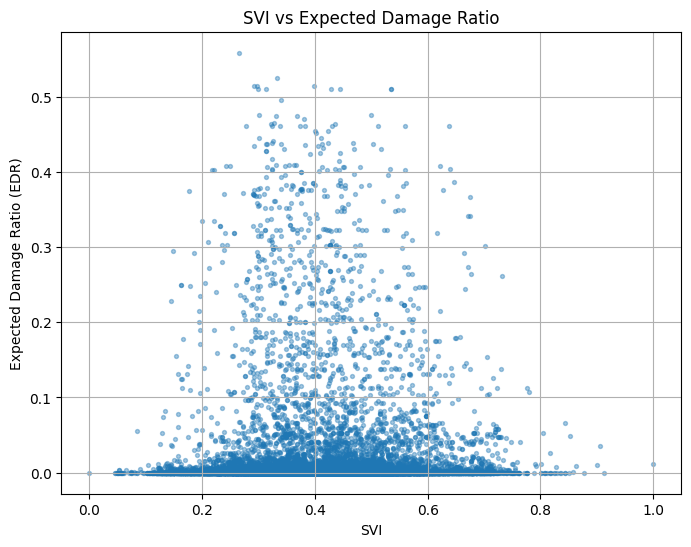

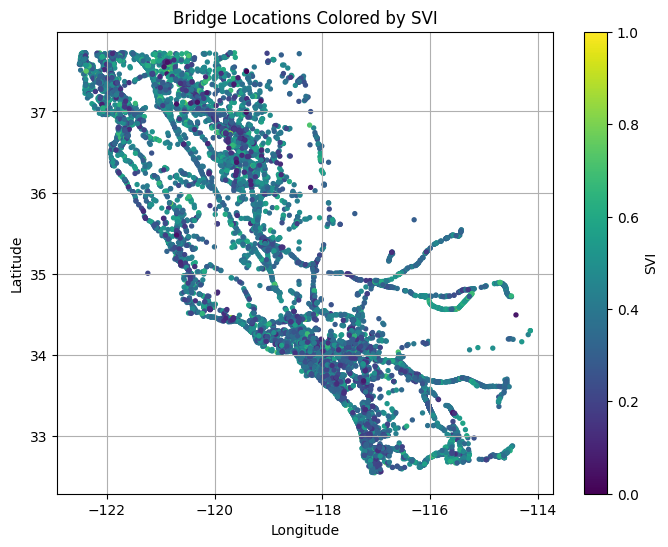

<Figure size 1200x600 with 0 Axes>

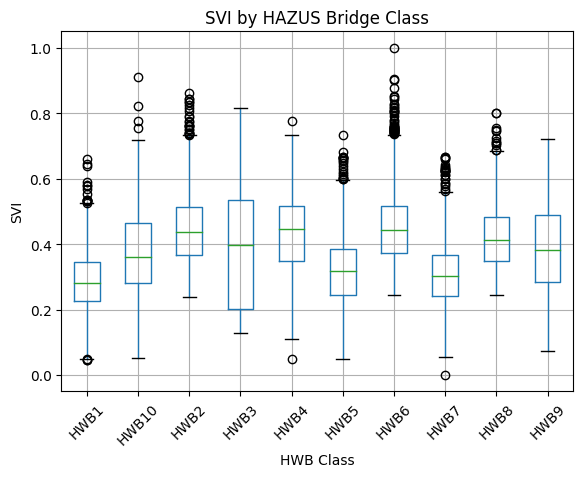

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

DOWNLOADS = Path.home() / "Downloads"
bridge_df = pd.read_csv(DOWNLOADS / "bridges_with_svi.csv", low_memory=False)

plt.figure(figsize=(8, 6))
plt.hist(bridge_df["SVI"].dropna(), bins=40)
plt.xlabel("SVI")
plt.ylabel("Count")
plt.title("Distribution of Seismic Vulnerability Index")
plt.grid(True)
plt.show()

plot_df = bridge_df.dropna(subset=["SVI", "EDR"]).copy()

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["SVI"], plot_df["EDR"], s=8, alpha=0.4)
plt.xlabel("SVI")
plt.ylabel("Expected Damage Ratio (EDR)")
plt.title("SVI vs Expected Damage Ratio")
plt.grid(True)
plt.show()

map_df = bridge_df.dropna(subset=["longitude", "latitude", "SVI"]).copy()

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    map_df["longitude"],
    map_df["latitude"],
    c=map_df["SVI"],
    s=8
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Bridge Locations Colored by SVI")
plt.grid(True)
plt.colorbar(sc, label="SVI")
plt.show()

top_classes = bridge_df["HWB_CLASS"].value_counts().head(10).index
box_df = bridge_df[bridge_df["HWB_CLASS"].isin(top_classes)].copy()

plt.figure(figsize=(12, 6))
box_df.boxplot(column="SVI", by="HWB_CLASS", grid=True)
plt.xlabel("HWB Class")
plt.ylabel("SVI")
plt.title("SVI by HAZUS Bridge Class")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

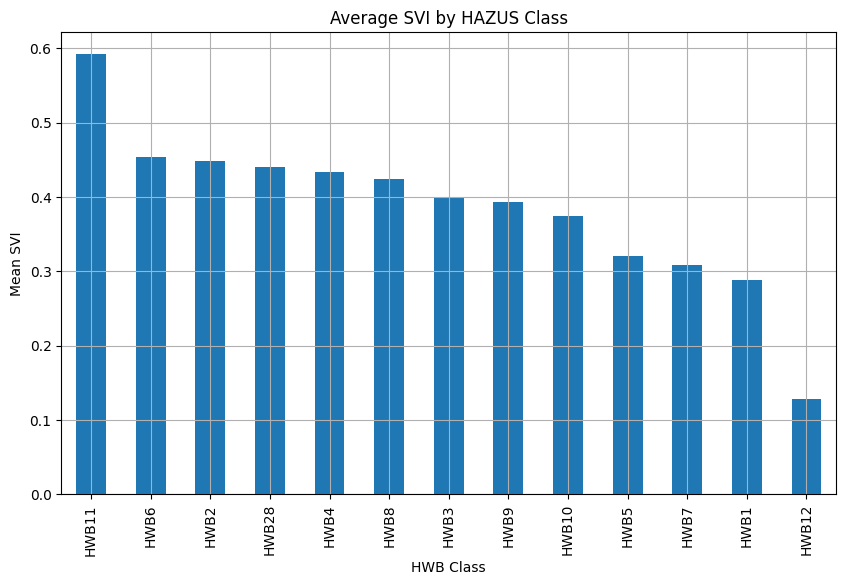

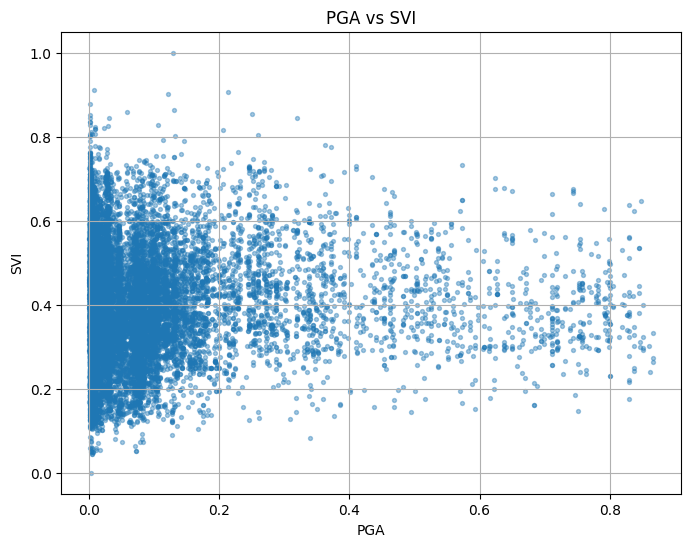

In [3]:
mean_svi_by_class = (
    bridge_df.groupby("HWB_CLASS")["SVI"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
mean_svi_by_class.plot(kind="bar")
plt.xlabel("HWB Class")
plt.ylabel("Mean SVI")
plt.title("Average SVI by HAZUS Class")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["pga"], plot_df["SVI"], s=8, alpha=0.4)
plt.xlabel("PGA")
plt.ylabel("SVI")
plt.title("PGA vs SVI")
plt.grid(True)
plt.show()

## Inference

The Part 3 plots show that the Seismic Vulnerability Index provides a meaningful continuous measure of bridge vulnerability across the dataset. The SVI histogram is roughly centered in the mid-range, which suggests that most bridges fall into moderate vulnerability levels rather than clustering only at the extremes. This is useful because it means the index captures variation across bridges instead of assigning nearly all of them to the same vulnerability level.

The SVI-by-HAZUS-class plots show that different HAZUS bridge classes tend to have different central SVI levels and spreads. This indicates that the SVI is consistent with the general structural logic of HAZUS, while still preserving more bridge-specific variation within each class. In other words, two bridges in the same HAZUS class can still have different SVI values depending on their age, reconstruction history, skew, span characteristics, and condition rating.

The spatial plot of bridges colored by SVI shows that vulnerability is distributed throughout the state rather than concentrated only in one location. This makes sense because SVI represents intrinsic bridge characteristics, not hazard intensity. The PGA versus SVI scatter plot further supports this interpretation by showing no strong direct dependence of SVI on PGA. That is an important result because it confirms that SVI is acting as a structural vulnerability measure rather than simply reflecting earthquake shaking.

Overall, Part 3 adds an interpretable bridge-level vulnerability metric that complements the HAZUS fragility approach. It creates a strong comparison layer for the project and provides an additional feature that can be carried forward into the machine learning stage.